<a href="https://colab.research.google.com/github/maxsccavalcante/Topicos_Especiais_em_TI/blob/main/Titanic_Classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/maxsccavalcante/FabricaSoftware/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação - Sobrevivência no Titanic

Neste trabalho eu uso a base de passageiros do Titanic para prever quem sobreviveu ao naufrágio. Como a variável que eu quero prever (`Survived`) só assume dois valores, 0 ou 1, este é um problema de **classificação binária**, e o algoritmo que uso é a **Regressão Logística**.

**Roteiro que segui:**
1. Imports e configuração
2. Carga dos dados
3. Análise exploratória
4. Engenharia de atributos
5. Separação entre features (X) e target (y)
6. Divisão treino/teste
7. Tratamento de valores ausentes
8. Padronização das features
9. Treinamento do modelo
10. Predições
11. Avaliação
12. Validação cruzada
13. Visualizações e interpretação
14. Conclusão

Base de dados: https://www.kaggle.com/datasets/yasserh/titanic-dataset

## 1. Imports e configuração

In [1]:
# Bibliotecas de manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Semente única para todo o notebook: garante que a divisão treino/teste e o modelo
# sejam sempre os mesmos, então os números que eu comento aqui se repetem a cada execução.
SEED = 42

print("Bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)

Bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


## 2. Carga dos dados



In [2]:
# Upload do arquivo CSV.
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Não estou no Colab - vou ler o arquivo local.")

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset carregado!")
print(f"Formato: {df.shape[0]} passageiros e {df.shape[1]} colunas")
display(df.head())

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv
Dataset carregado!
Formato: 891 passageiros e 12 colunas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Análise exploratória

**O que cada coluna representa:**

| Coluna | Significado |
|---|---|
| `PassengerId` | Identificador sequencial do passageiro |
| `Survived` | Target: 0 = não sobreviveu, 1 = sobreviveu |
| `Pclass` | Classe da passagem (1ª, 2ª ou 3ª) |
| `Name` | Nome completo, com o título social |
| `Sex` | Sexo do passageiro |
| `Age` | Idade em anos |
| `SibSp` | Número de irmãos/cônjuges a bordo |
| `Parch` | Número de pais/filhos a bordo |
| `Ticket` | Código da passagem |
| `Fare` | Valor pago pela passagem |
| `Cabin` | Cabine ocupada |
| `Embarked` | Porto de embarque (C, Q ou S) |



In [3]:
# Estrutura geral: tipos de dado e quantidade de valores preenchidos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Resumo estatístico das colunas numéricas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Levantamento dos valores ausentes, em quantidade e em percentual.
ausentes = pd.DataFrame({
    'ausentes': df.isnull().sum(),
    'percentual': (df.isnull().sum() / len(df) * 100).round(2)
})

ausentes[ausentes['ausentes'] > 0].sort_values('ausentes', ascending = False)

,ausentes,percentual
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


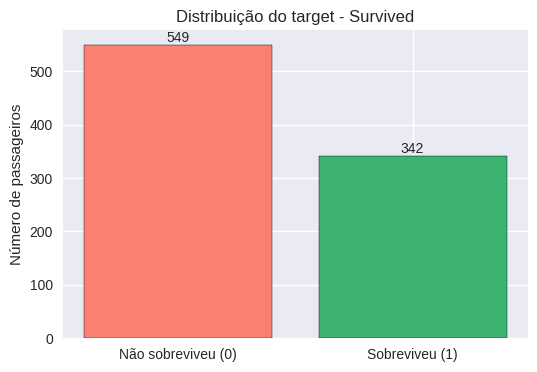

Proporção de cada classe:
Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

Classe majoritária: 61.6% -> é essa a taxa de acerto que eu bateria
chutando sempre 'não sobreviveu'. O modelo precisa superar esse valor para valer a pena.


In [6]:
# Distribuição do target com representação em barras para saber se as classes estão equilibradas.
contagem = df['Survived'].value_counts().sort_index()
proporcao = df['Survived'].value_counts(normalize = True).sort_index()

plt.figure(figsize = (6, 4))
plt.bar(['Não sobreviveu (0)', 'Sobreviveu (1)'], contagem.values, color = ['salmon', 'mediumseagreen'], edgecolor = 'black')
plt.ylabel('Número de passageiros')
plt.title('Distribuição do target - Survived')
for i, v in enumerate(contagem.values):
    plt.text(i, v + 5, str(v), ha = 'center')
plt.show()

print("Proporção de cada classe:")
print(proporcao.round(4))
print()
print(f"Classe majoritária: {proporcao.max() * 100:.1f}% -> é essa a taxa de acerto que eu bateria")
print("chutando sempre 'não sobreviveu'. O modelo precisa superar esse valor para valer a pena.")

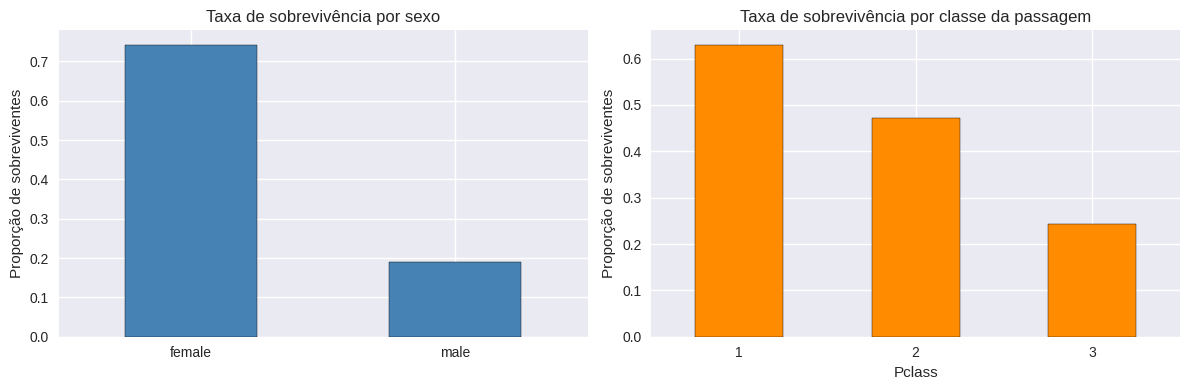

        count   mean
Sex                 
female    314  0.742
male      577  0.189

        count   mean
Pclass              
1         216  0.630
2         184  0.473
3         491  0.242


In [7]:
# Taxa de sobrevivência por sexo e por classe da passagem.
# Faço isso antes de modelar para já ter uma ideia de quais variáveis devem pesar mais.
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

df.groupby('Sex')['Survived'].mean().plot(kind = 'bar', ax = axes[0], color = 'steelblue', edgecolor = 'black')
axes[0].set_title('Taxa de sobrevivência por sexo')
axes[0].set_ylabel('Proporção de sobreviventes')
axes[0].set_xlabel('')
axes[0].tick_params(axis = 'x', rotation = 0)

df.groupby('Pclass')['Survived'].mean().plot(kind = 'bar', ax = axes[1], color = 'darkorange', edgecolor = 'black')
axes[1].set_title('Taxa de sobrevivência por classe da passagem')
axes[1].set_ylabel('Proporção de sobreviventes')
axes[1].set_xlabel('Pclass')
axes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

print(df.groupby('Sex')['Survived'].agg(['count', 'mean']).round(3))
print()
print(df.groupby('Pclass')['Survived'].agg(['count', 'mean']).round(3))

## 4. Engenharia de atributos

**Decisões de classificação de pessoas e famílias:**
- `FamilySize` = irmãos/cônjuges + pais/filhos + 1 (o próprio passageiro): resume o tamanho do grupo familiar a bordo.
- `IsAlone`: marca quem viajava sozinho, porque essa condição mudava bastante a chance de conseguir lugar em um bote.
- `Title`: extraio o título do nome (Mr, Mrs, Miss, Master) porque ele carrega sexo, estado civil e idade aproximada de uma vez só. Agrupo os títulos raros em "Outros" para não criar dezenas de colunas com pouquíssimas ocorrências.
- Removo `Cabin`: tem quase 80% de valores ausentes, não vale a pena imputar.
- Removo `PassengerId`, `Name` e `Ticket`: são identificadores ou texto livre, sem poder preditivo depois que já extraí o título.

In [8]:
# Trabalho sobre uma cópia para manter o df original intacto
df_prep = df.copy()

# Tamanho da família a bordo (inclui o próprio passageiro)
df_prep['FamilySize'] = df_prep['SibSp'] + df_prep['Parch'] + 1

# Indica se o passageiro estava viajando sozinho
df_prep['IsAlone'] = (df_prep['FamilySize'] == 1).astype(int)

# Extraio o título que aparece entre a vírgula e o ponto no nome (ex: "Braund, Mr. Owen Harris" -> "Mr")
df_prep['Title'] = df_prep['Name'].str.extract(r',\s*([^.]*)\.')[0].str.strip()

print("Títulos encontrados antes do agrupamento:")
print(df_prep['Title'].value_counts())

# Mantenho só os quatro títulos frequentes e jogo o resto em 'Outros'
titulos_principais = ['Mr', 'Mrs', 'Miss', 'Master']
df_prep['Title'] = df_prep['Title'].where(df_prep['Title'].isin(titulos_principais), 'Outros')

print()
print("Depois do agrupamento:")
print(df_prep['Title'].value_counts())

Títulos encontrados antes do agrupamento:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Depois do agrupamento:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Outros     27
Name: count, dtype: int64


In [9]:
# Confiro se as features novas fazem sentido antes de descartar as colunas de origem
display(df_prep[['Name', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Title']].head(10))

,Name,SibSp,Parch,FamilySize,IsAlone,Title
0,"Braund, Mr. Owen Harris",1,0,2,0,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,0,Mrs
2,"Heikkinen, Miss. Laina",0,0,1,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,0,Mrs
4,"Allen, Mr. William Henry",0,0,1,1,Mr
5,"Moran, Mr. James",0,0,1,1,Mr
6,"McCarthy, Mr. Timothy J",0,0,1,1,Mr
7,"Palsson, Master. Gosta Leonard",3,1,5,0,Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,2,3,0,Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",1,0,2,0,Mrs


In [10]:
# Removo as colunas que não vou usar. Uso uma lista com verificação para a célula continuar funcionando mesmo se eu rodar duas vezes seguidas.
cols_remover = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_prep = df_prep.drop(columns = [c for c in cols_remover if c in df_prep.columns])

print("Formato depois da limpeza:", df_prep.shape)
print("Colunas restantes:", df_prep.columns.tolist())
display(df_prep.head())

Formato depois da limpeza: (891, 11)
Colunas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


## 5. Separação entre features (X) e target (y)

- **X (features)**: tudo o que uso como entrada para prever.
- **y (target)**: a coluna `Survived`, que é o que quero descobrir.


In [11]:
# Defino X e y uma única vez, já com os dados preparados
X = df_prep.drop(columns = ['Survived'])
y = df_prep['Survived']

print(f"X: {X.shape[0]} amostras e {X.shape[1]} features")
print(f"Features: {X.columns.tolist()}")
print(f"y: {y.shape[0]} valores | classes: {sorted(y.unique())}")

X: 891 amostras e 10 features
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']
y: 891 valores | classes: [np.int64(0), np.int64(1)]


## 6. Divisão treino/teste

Separo 80% para treino e 20% para teste. O modelo aprende só com o treino, e o teste fica reservado para simular dados que ele nunca viu.

Usei `stratify=y` para manter a mesma proporção de sobreviventes nos dois conjuntos. Sem isso, o sorteio pode deixar o teste desbalanceado e a avaliação fica enganosa.

In [12]:
# Divisão estratificada: preserva a proporção entre sobreviventes e não sobreviventes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = SEED,
    stratify = y
)

print("=== DIVISÃO DOS DADOS ===")
print(f"Treino: {X_train.shape[0]} passageiros ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Teste:  {X_test.shape[0]} passageiros ({X_test.shape[0] / len(X) * 100:.1f}%)")

print("\n=== PROPORÇÃO DE SOBREVIVENTES ===")
print(f"Base completa: {y.mean():.4f}")
print(f"Treino:        {y_train.mean():.4f}")
print(f"Teste:         {y_test.mean():.4f}")
print("\nAs três proporções ficaram praticamente iguais - foi o stratify que garantiu isso.")

=== DIVISÃO DOS DADOS ===
Treino: 712 passageiros (79.9%)
Teste:  179 passageiros (20.1%)

=== PROPORÇÃO DE SOBREVIVENTES ===
Base completa: 0.3838
Treino:        0.3834
Teste:         0.3855

As três proporções ficaram praticamente iguais - foi o stratify que garantiu isso.


## 7. Tratamento dos valores ausentes


In [13]:
# Estatísticas calculadas SOMENTE no treino
idade_mediana = X_train['Age'].median()
porto_mais_comum = X_train['Embarked'].mode()[0]

print(f"Mediana da idade no treino: {idade_mediana:.2f}")
print(f"Porto de embarque mais comum no treino: {porto_mais_comum}")

# Aplico os mesmos valores nos dois conjuntos
X_train['Age'] = X_train['Age'].fillna(idade_mediana)
X_test['Age'] = X_test['Age'].fillna(idade_mediana)

X_train['Embarked'] = X_train['Embarked'].fillna(porto_mais_comum)
X_test['Embarked'] = X_test['Embarked'].fillna(porto_mais_comum)

print("\nValores ausentes restantes no treino:", X_train.isnull().sum().sum())
print("Valores ausentes restantes no teste:", X_test.isnull().sum().sum())

Mediana da idade no treino: 28.50
Porto de embarque mais comum no treino: S

Valores ausentes restantes no treino: 0
Valores ausentes restantes no teste: 0


## 8. Codificação das categóricas e padronização


In [14]:
# One-Hot Encoding das variáveis categóricas
cols_categoricas = ['Sex', 'Embarked', 'Title']

X_train = pd.get_dummies(X_train, columns = cols_categoricas, drop_first = True, dtype = float)
X_test = pd.get_dummies(X_test, columns = cols_categoricas, drop_first = True, dtype = float)

# Garanto que o teste tenha exatamente as mesmas colunas do treino, na mesma ordem
X_test = X_test.reindex(columns = X_train.columns, fill_value = 0.0)

print("Features depois da codificação:", X_train.shape[1])
print(X_train.columns.tolist())
display(X_train.head())

Features depois da codificação: 14
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Outros']


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Outros
692,3,28.5,0,0,56.4958,1,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0
481,2,28.5,0,0,0.0000,1,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0
527,1,28.5,0,0,221.7792,1,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0
855,3,18.0,0,1,9.3500,2,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
801,2,31.0,1,1,26.2500,3,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [15]:
print("=== ANTES DA PADRONIZAÇÃO ===")
display(X_train.describe().round(2))

# O scaler aprende média e desvio apenas no treino...
scaler = StandardScaler()
scaler.fit(X_train)

# ...e a mesma transformação é aplicada nos dois conjuntos
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

print("\n=== DEPOIS DA PADRONIZAÇÃO ===")
display(X_train_scaled.describe().round(2))
print("Todas as features do treino agora têm média ≈ 0 e desvio ≈ 1.")

=== ANTES DA PADRONIZAÇÃO ===


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Outros
count,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.0,712.00,712.00,712.00
mean,2.31,29.56,0.49,0.39,31.82,1.88,0.61,0.64,0.08,0.73,0.2,0.58,0.15,0.03
std,0.83,13.03,1.06,0.84,48.06,1.59,0.49,0.48,0.27,0.45,0.4,0.49,0.36,0.17
min,1.00,0.42,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,2.00,22.00,0.00,0.00,7.90,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,3.00,28.50,0.00,0.00,14.45,1.00,1.00,1.00,0.00,1.00,0.0,1.00,0.00,0.00
75%,3.00,36.00,1.00,0.00,31.00,2.00,1.00,1.00,0.00,1.00,0.0,1.00,0.00,0.00
max,3.00,80.00,8.00,6.00,512.33,11.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00



=== DEPOIS DA PADRONIZAÇÃO ===


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Outros
count,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00,712.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.57,-2.24,-0.47,-0.47,-0.66,-0.56,-1.25,-1.35,-0.29,-1.63,-0.50,-1.17,-0.42,-0.17
25%,-0.37,-0.58,-0.47,-0.47,-0.50,-0.56,-1.25,-1.35,-0.29,-1.63,-0.50,-1.17,-0.42,-0.17
50%,0.83,-0.08,-0.47,-0.47,-0.36,-0.56,0.80,0.74,-0.29,0.61,-0.50,0.85,-0.42,-0.17
75%,0.83,0.50,0.48,-0.47,-0.02,0.07,0.80,0.74,-0.29,0.61,-0.50,0.85,-0.42,-0.17
max,0.83,3.88,7.08,6.70,10.01,5.74,0.80,0.74,3.46,0.61,2.01,0.85,2.38,5.74


Todas as features do treino agora têm média ≈ 0 e desvio ≈ 1.


## 9. Treinamento do modelo

Uso a **Regressão Logística**, que é o modelo linear para classificação. Em vez de prever um número qualquer, ela passa a combinação linear das features por uma função sigmoide, o que força o resultado a ficar entre 0 e 1 e permite ler a saída como probabilidade de sobrevivência.


In [16]:
modelo = LogisticRegression(max_iter = 1000, random_state = SEED)

print("=== TREINAMENTO ===")
print(f"Modelo: {modelo}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

modelo.fit(X_train_scaled, y_train)

print("Treinamento concluído!")
print(f"\nIntercepto: {modelo.intercept_[0]:.4f}")

coeficientes = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coeficiente': modelo.coef_[0],
    'razao_de_chances': np.exp(modelo.coef_[0])
}).sort_values('coeficiente', key = abs, ascending = False).reset_index(drop = True)

print("\n=== COEFICIENTES (ordenados por influência) ===")
display(coeficientes.round(4))

=== TREINAMENTO ===
Modelo: LogisticRegression(max_iter=1000, random_state=42)
Treinando com 712 amostras e 14 features
Treinamento concluído!

Intercepto: -0.6890

=== COEFICIENTES (ordenados por influência) ===


,feature,coeficiente,razao_de_chances
0,Title_Mr,-1.3421,0.2613
1,Pclass,-0.8516,0.4267
2,Sex_male,-0.8396,0.4319
3,Title_Miss,-0.6754,0.5089
4,Title_Mrs,-0.3756,0.6869
5,Age,-0.3727,0.6889
6,Title_Outros,-0.3553,0.7010
7,SibSp,-0.3492,0.7053
8,FamilySize,-0.3074,0.7354
9,IsAlone,-0.1899,0.8270


## 10. Predições

A Regressão Logística me dá duas saídas: a classe prevista (`predict`) e a probabilidade de sobrevivência (`predict_proba`). Guardo as duas. A probabilidade é o que uso depois para calcular a AUC e traçar a curva ROC.

In [17]:
# Classe prevista (0 ou 1)
y_train_pred = modelo.predict(X_train_scaled)
y_test_pred = modelo.predict(X_test_scaled)

# Probabilidade prevista de sobreviver (coluna 1 = classe positiva)
y_train_proba = modelo.predict_proba(X_train_scaled)[:, 1]
y_test_proba = modelo.predict_proba(X_test_scaled)[:, 1]

print("=== EXEMPLOS DO CONJUNTO DE TESTE ===")
exemplos = pd.DataFrame({
    'real': y_test[:10],
    'previsto': y_test_pred[:10],
    'prob_sobreviver': y_test_proba[:10].round(3),
    'acertou': y_test[:10].values == y_test_pred[:10]
})
display(exemplos)

=== EXEMPLOS DO CONJUNTO DE TESTE ===


,real,previsto,prob_sobreviver,acertou
565,0,0,0.047,True
160,0,0,0.052,True
553,1,0,0.120,False
860,0,0,0.029,True
241,1,1,0.694,True
559,1,1,0.641,True
387,1,1,0.746,True
536,0,0,0.432,True
698,0,0,0.287,True
99,0,0,0.150,True


## 11. Avaliação do modelo


- **Acurácia**: percentual geral de acertos. Sozinha ela engana quando as classes são desbalanceadas.
- **Precisão**: dos que o modelo disse que sobreviveram, quantos realmente sobreviveram.
- **Recall**: dos que realmente sobreviveram, quantos o modelo conseguiu identificar.
- **F1-Score**: média harmônica entre precisão e recall, útil para resumir as duas em um número.
- **AUC-ROC**: mede a capacidade do modelo de ordenar corretamente os casos por probabilidade, independente do limiar de corte. 0,5 é o equivalente a jogar uma moeda.

Comparo tudo com o *baseline* de chutar sempre a classe majoritária, que é o mínimo que qualquer modelo precisa superar.

In [18]:
def avaliar(y_true, y_pred, y_proba, nome_conjunto):
    """Calcula e exibe as métricas de classificação de um conjunto"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"=== CONJUNTO DE {nome_conjunto.upper()} ===")
    print(f"Acurácia:  {acc:.4f} ({acc * 100:.2f}% de acerto)")
    print(f"Precisão:  {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")

    return acc, prec, rec, f1, auc

treino_m = avaliar(y_train, y_train_pred, y_train_proba, "treino")
print()
teste_m = avaliar(y_test, y_test_pred, y_test_proba, "teste")

# Comparativo com o baseline
baseline = y_test.value_counts(normalize = True).max()
print(f"\n=== COMPARAÇÃO COM O BASELINE ===")
print(f"Chutar sempre a classe majoritária: {baseline:.4f}")
print(f"Acurácia do modelo no teste:        {teste_m[0]:.4f}")
print(f"Ganho sobre o baseline:             {(teste_m[0] - baseline) * 100:+.2f} pontos percentuais")

# Checagem de overfitting
dif = treino_m[0] - teste_m[0]
print(f"\nDiferença de acurácia treino - teste: {dif:.4f}")
if dif > 0.10:
    print("Diferença alta: sinal de overfitting, o modelo decorou o treino.")
elif abs(dif) < 0.05:
    print("Diferença pequena: o modelo está generalizando bem.")
else:
    print("Diferença moderada, mas ainda aceitável.")

=== CONJUNTO DE TREINO ===
Acurácia:  0.8301 (83.01% de acerto)
Precisão:  0.7946
Recall:    0.7509
F1-Score:  0.7721
AUC-ROC:   0.8733

=== CONJUNTO DE TESTE ===
Acurácia:  0.8547 (85.47% de acerto)
Precisão:  0.8413
Recall:    0.7681
F1-Score:  0.8030
AUC-ROC:   0.8798

=== COMPARAÇÃO COM O BASELINE ===
Chutar sempre a classe majoritária: 0.6145
Acurácia do modelo no teste:        0.8547
Ganho sobre o baseline:             +24.02 pontos percentuais

Diferença de acurácia treino - teste: -0.0247
Diferença pequena: o modelo está generalizando bem.


In [19]:
# Relatório completo por classe
print("=== RELATÓRIO DE CLASSIFICAÇÃO (conjunto de teste) ===")
print(classification_report(y_test, y_test_pred, target_names = ['Não sobreviveu', 'Sobreviveu']))

=== RELATÓRIO DE CLASSIFICAÇÃO (conjunto de teste) ===
                precision    recall  f1-score   support

Não sobreviveu       0.86      0.91      0.88       110
    Sobreviveu       0.84      0.77      0.80        69

      accuracy                           0.85       179
     macro avg       0.85      0.84      0.84       179
  weighted avg       0.85      0.85      0.85       179



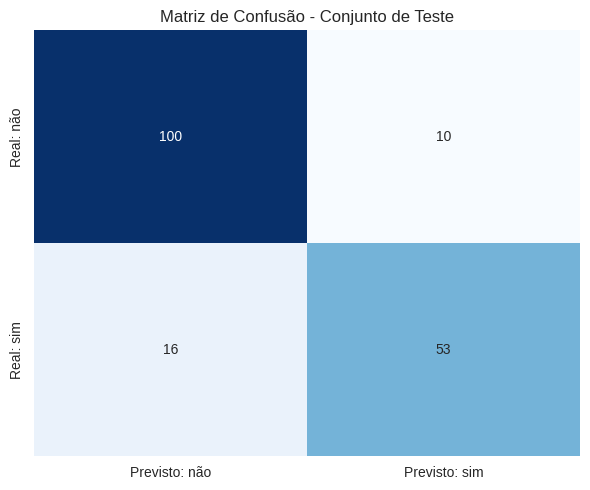

Verdadeiros negativos: 100  (não sobreviveu e o modelo acertou)
Falsos positivos:      10  (o modelo disse que sobreviveu, mas não sobreviveu)
Falsos negativos:      16  (sobreviveu, mas o modelo não identificou)
Verdadeiros positivos: 53  (sobreviveu e o modelo acertou)


In [20]:
# Matriz de confusão: mostra exatamente onde o modelo erra.
# A diagonal principal são os acertos; fora dela, os dois tipos de erro.
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False,
            xticklabels = ['Previsto: não', 'Previsto: sim'],
            yticklabels = ['Real: não', 'Real: sim'])
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Verdadeiros negativos: {vn}  (não sobreviveu e o modelo acertou)")
print(f"Falsos positivos:      {fp}  (o modelo disse que sobreviveu, mas não sobreviveu)")
print(f"Falsos negativos:      {fn}  (sobreviveu, mas o modelo não identificou)")
print(f"Verdadeiros positivos: {vp}  (sobreviveu e o modelo acertou)")

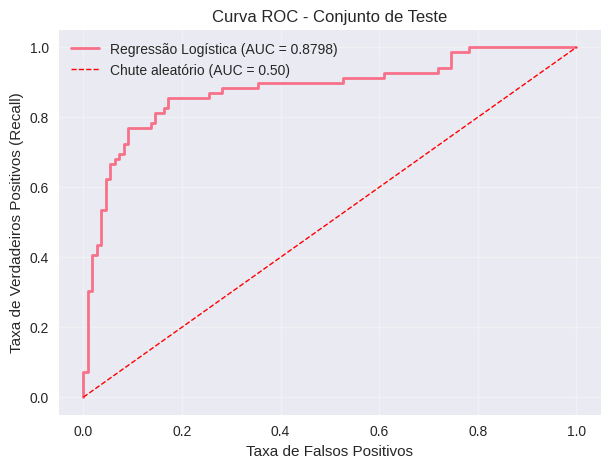

In [21]:
# Curva ROC: mostra o equilíbrio entre acertar os sobreviventes e errar os não sobreviventes
# conforme eu movo o limiar de decisão. A diagonal tracejada é o desempenho de um chute aleatório.
fpr, tpr, limiares = roc_curve(y_test, y_test_proba)

plt.figure(figsize = (7, 5))
plt.plot(fpr, tpr, linewidth = 2, label = f'Regressão Logística (AUC = {teste_m[4]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth = 1, label = 'Chute aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC - Conjunto de Teste')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

## 12. Validação cruzada

O conjunto de teste tem só 179 passageiros, então o resultado depende bastante de quais passageiros caíram nele por sorteio. Para ter uma estimativa mais confiável, é feito uma validação cruzada com 5 divisões estratificadas: a base é dividida em 5 partes e o modelo é treinado e testado 5 vezes, revezando qual parte fica de fora.


In [22]:
# Preparo a base completa para a validação cruzada
X_cv = X.copy()
X_cv['Embarked'] = X_cv['Embarked'].fillna(porto_mais_comum)
X_cv = pd.get_dummies(X_cv, columns = cols_categoricas, drop_first = True, dtype = float)

# A imputação da idade e a padronização entram no pipeline, refeitas a cada divisão
pipeline = Pipeline([
    ('imputador', SimpleImputer(strategy = 'median')),
    ('escalonador', StandardScaler()),
    ('modelo', LogisticRegression(max_iter = 1000, random_state = SEED))
])

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = SEED)

scores_acc = cross_val_score(pipeline, X_cv, y, cv = cv, scoring = 'accuracy')
scores_auc = cross_val_score(pipeline, X_cv, y, cv = cv, scoring = 'roc_auc')

print("=== VALIDAÇÃO CRUZADA (5 divisões) ===")
print("Acurácia por divisão:", scores_acc.round(4))
print(f"Acurácia média: {scores_acc.mean():.4f} (+/- {scores_acc.std():.4f})")
print()
print("AUC por divisão:", scores_auc.round(4))
print(f"AUC média: {scores_auc.mean():.4f} (+/- {scores_auc.std():.4f})")

=== VALIDAÇÃO CRUZADA (5 divisões) ===
Acurácia por divisão: [0.8436 0.8146 0.8315 0.8315 0.8315]
Acurácia média: 0.8305 (+/- 0.0092)

AUC por divisão: [0.8894 0.8675 0.8557 0.8505 0.898 ]
AUC média: 0.8722 (+/- 0.0186)


## 13. Interpretação das features

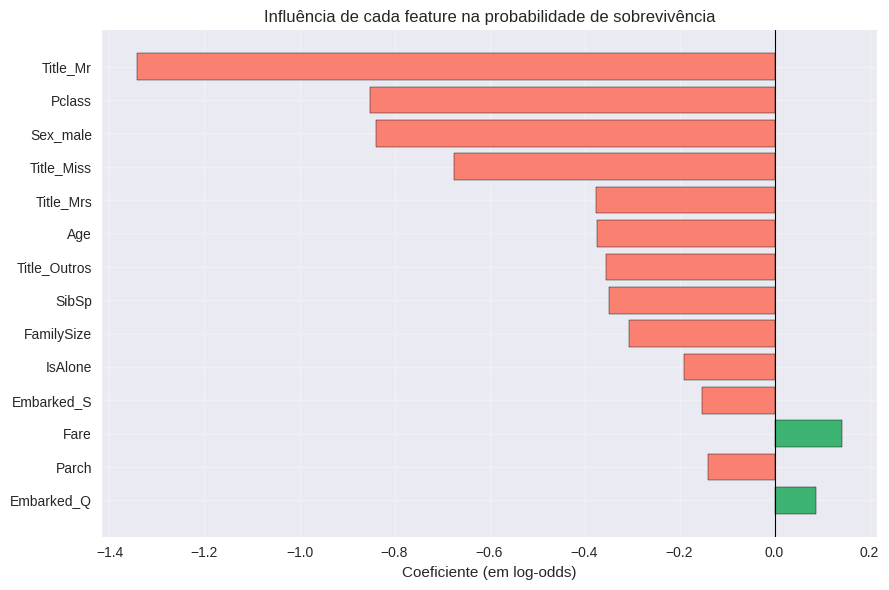

=== AS 5 FEATURES MAIS INFLUENTES ===
• Title_Mr: DIMINUI a chance de sobreviver (coef = -1.3421, razão de chances = 0.261)
• Pclass: DIMINUI a chance de sobreviver (coef = -0.8516, razão de chances = 0.427)
• Sex_male: DIMINUI a chance de sobreviver (coef = -0.8396, razão de chances = 0.432)
• Title_Miss: DIMINUI a chance de sobreviver (coef = -0.6754, razão de chances = 0.509)
• Title_Mrs: DIMINUI a chance de sobreviver (coef = -0.3756, razão de chances = 0.687)


In [23]:
# Gráfico de influência das features
plt.figure(figsize = (9, 6))
cores = ['mediumseagreen' if c > 0 else 'salmon' for c in coeficientes['coeficiente']]
plt.barh(coeficientes['feature'], coeficientes['coeficiente'], color = cores, edgecolor = 'black')
plt.axvline(x = 0, color = 'black', linewidth = 0.8)
plt.xlabel('Coeficiente (em log-odds)')
plt.title('Influência de cada feature na probabilidade de sobrevivência')
plt.grid(True, alpha = 0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("=== AS 5 FEATURES MAIS INFLUENTES ===")
for _, linha in coeficientes.head(5).iterrows():
    direcao = "AUMENTA" if linha['coeficiente'] > 0 else "DIMINUI"
    print(f"• {linha['feature']}: {direcao} a chance de sobreviver "
          f"(coef = {linha['coeficiente']:.4f}, razão de chances = {linha['razao_de_chances']:.3f})")

In [24]:
# Exemplo de predição individual, para mostrar como o modelo funciona na prática
idx = 0
passageiro = X_test_scaled.iloc[idx:idx + 1]
real = y_test.iloc[idx]
prob = modelo.predict_proba(passageiro)[0, 1]
previsto = modelo.predict(passageiro)[0]

print("=== EXEMPLO DE PREDIÇÃO ===")
print("Dados do passageiro (antes da padronização):")
display(X_test.iloc[idx:idx + 1])

print(f"Probabilidade de sobrevivência calculada: {prob:.2%}")
print(f"Classe prevista: {previsto} | Classe real: {real}")
print("Resultado:", "acertou" if previsto == real else "errou")

=== EXEMPLO DE PREDIÇÃO ===
Dados do passageiro (antes da padronização):


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Outros
565,3,24.0,2,0,24.15,3,0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


Probabilidade de sobrevivência calculada: 4.74%
Classe prevista: 0 | Classe real: 0
Resultado: acertou


## 14. Conclusão

**O que eu fiz neste notebook:** carreguei a base do Titanic, explorei a estrutura e os valores ausentes, criei três features novas a partir dos dados existentes (`FamilySize`, `IsAlone` e `Title`), tratei os vazios usando apenas estatísticas do treino, codifiquei as categóricas, padronizei tudo e treinei uma Regressão Logística, avaliada com métricas de classificação e confirmada por validação cruzada.

**O que os resultados mostram:** o modelo ficou bem acima do baseline de chutar sempre "não sobreviveu" (~61,6%), e a AUC confirma que ele separa razoavelmente bem os dois grupos. Olhando os coeficientes, o sexo é de longe a variável mais decisiva — ser homem reduz drasticamente a chance prevista de sobrevivência —, seguido pela classe da passagem, pelo título e pela idade. Isso bate com o que já se sabe historicamente sobre o protocolo de evacuação do Titanic, que priorizou mulheres e crianças, e com a vantagem de quem viajava na primeira classe, mais próxima do convés dos botes.

